In [1]:
import urllib.request

url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv"
urllib.request.urlretrieve(url, "d:\\climate-portfolio\\ZonAnn.Ts+dSST.csv")
print("Downloaded!")

Downloaded!


In [3]:
import pandas as pd
df = pd.read_csv('ZonAnn.Ts+dSST.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(146, 15)
   Year  Glob  NHem  SHem  24N-90N  24S-24N  90S-24S  64N-90N  44N-64N  \
0  1880 -0.18 -0.30 -0.05    -0.39    -0.13    -0.01    -0.79    -0.49   
1  1881 -0.09 -0.19  0.00    -0.36     0.10    -0.07    -0.85    -0.44   
2  1882 -0.11 -0.22 -0.01    -0.31    -0.05     0.01    -1.34    -0.26   
3  1883 -0.17 -0.29 -0.07    -0.34    -0.17    -0.01    -0.12    -0.54   
4  1884 -0.28 -0.43 -0.15    -0.60    -0.15    -0.14    -1.26    -0.63   

   24N-44N  EQU-24N  24S-EQU  44S-24S  64S-44S  90S-64S  
0    -0.32    -0.15    -0.11    -0.04     0.05     0.69  
1    -0.24     0.09     0.10    -0.06    -0.07     0.61  
2    -0.17    -0.06    -0.05     0.01     0.04     0.64  
3    -0.28    -0.18    -0.15    -0.04     0.07     0.52  
4    -0.48    -0.14    -0.17    -0.19    -0.02     0.67  
['Year', 'Glob', 'NHem', 'SHem', '24N-90N', '24S-24N', '90S-24S', '64N-90N', '44N-64N', '24N-44N', 'EQU-24N', '24S-EQU', '44S-24S', '64S-44S', '90S-64S']


In [4]:
# Check for missing values
print(df.isnull().sum())
print("\nYear range:", df['Year'].min(), "to", df['Year'].max())

Year       0
Glob       0
NHem       0
SHem       0
24N-90N    0
24S-24N    0
90S-24S    0
64N-90N    0
44N-64N    0
24N-44N    0
EQU-24N    0
24S-EQU    0
44S-24S    0
64S-44S    0
90S-64S    0
dtype: int64

Year range: 1880 to 2025


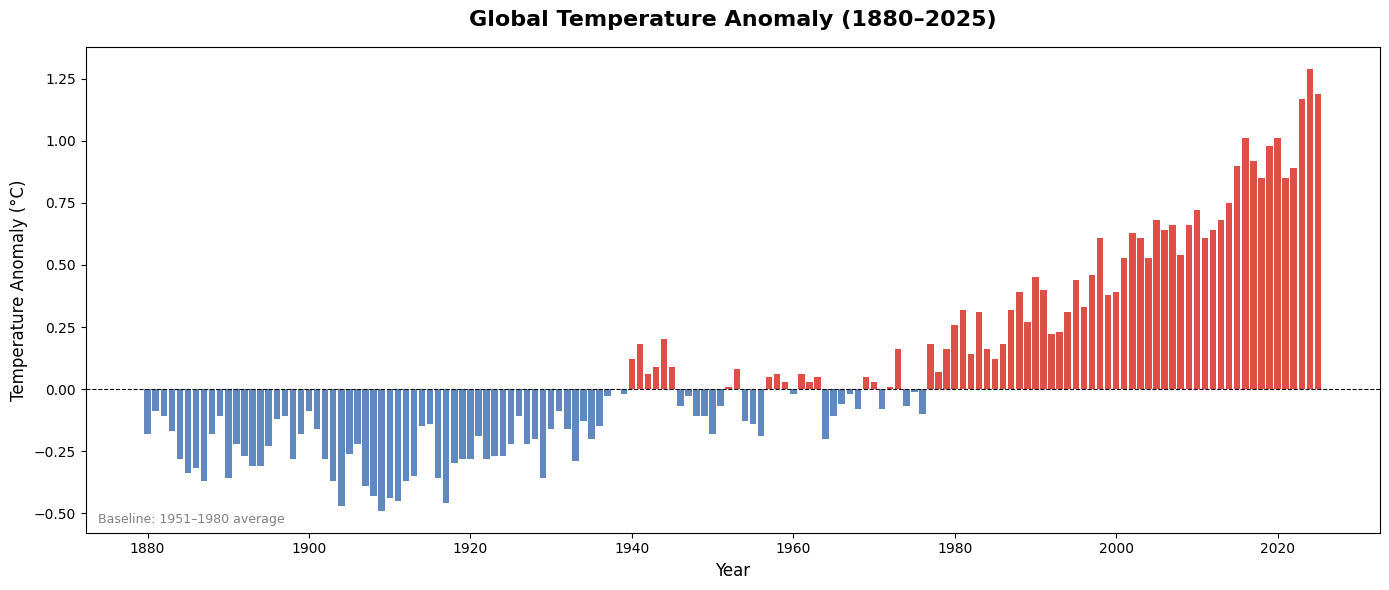

Saved!


In [6]:
# Plot 1 — Global Temperature Anomaly Over Time
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#d73027' if x > 0 else '#4575b4' for x in df['Glob']]
ax.bar(df['Year'], df['Glob'], color=colors, width=0.8, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Global Temperature Anomaly (1880–2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax.annotate('Baseline: 1951–1980 average', xy=(0.01, 0.02),
            xycoords='axes fraction', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('plot1_global_anomaly.png', dpi=150)
plt.show()
print("Saved!")


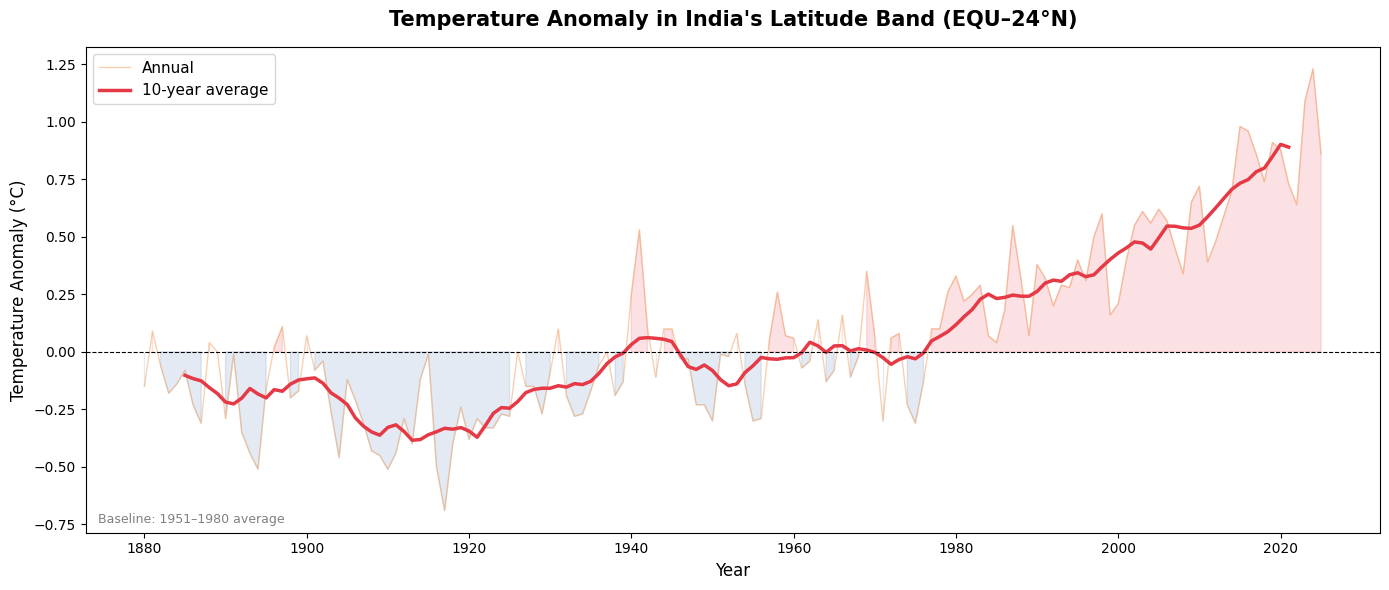

Saved!


In [7]:
# Plot 2 — India Region Temperature Trend with Smoothing
fig, ax = plt.subplots(figsize=(14, 6))

# Raw annual values
ax.plot(df['Year'], df['EQU-24N'], color='#f4a261', linewidth=1, alpha=0.5, label='Annual')

# 10-year rolling average
rolling = df['EQU-24N'].rolling(window=10, center=True).mean()
ax.plot(df['Year'], rolling, color='#e63946', linewidth=2.5, label='10-year average')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(df['Year'], df['EQU-24N'], 0,
                where=df['EQU-24N'] > 0, alpha=0.15, color='#e63946')
ax.fill_between(df['Year'], df['EQU-24N'], 0,
                where=df['EQU-24N'] < 0, alpha=0.15, color='#4575b4')

ax.set_title("Temperature Anomaly in India's Latitude Band (EQU–24°N)", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax.legend(fontsize=11)
ax.annotate('Baseline: 1951–1980 average', xy=(0.01, 0.02),
            xycoords='axes fraction', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('plot2_india_region_trend.png', dpi=150)
plt.show()
print("Saved!")

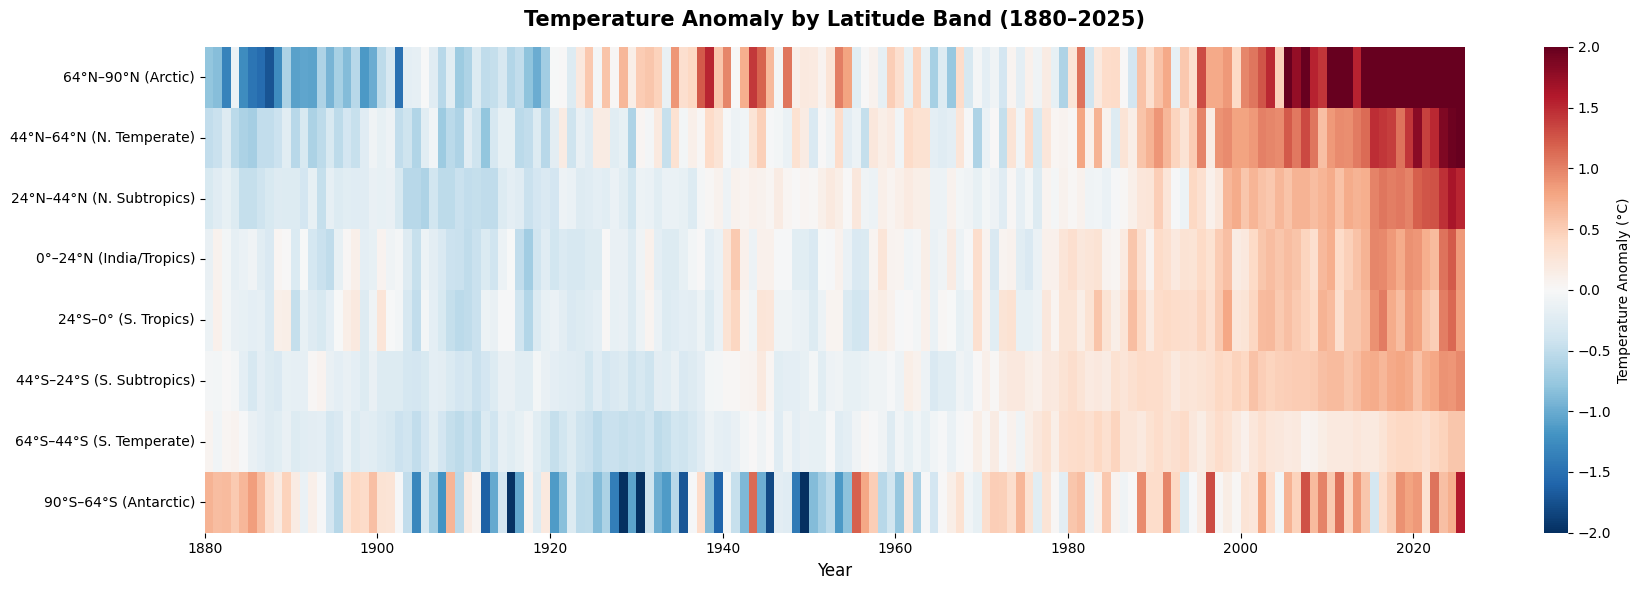

Saved!


In [9]:
# Plot 3 — Heatmap of Temperature Anomalies Across Latitude Bands
import seaborn as sns
zone_cols = ['64N-90N', '44N-64N', '24N-44N', 'EQU-24N', '24S-EQU', '44S-24S', '64S-44S', '90S-64S']

zone_labels = ['64°N–90°N (Arctic)', '44°N–64°N (N. Temperate)', '24°N–44°N (N. Subtropics)',
               '0°–24°N (India/Tropics)', '24°S–0° (S. Tropics)', '44°S–24°S (S. Subtropics)',
               '64°S–44°S (S. Temperate)', '90°S–64°S (Antarctic)']

heatmap_data = df[zone_cols].T
heatmap_data.columns = df['Year']
heatmap_data.index = zone_labels

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
            ax=ax, cbar_kws={'label': 'Temperature Anomaly (°C)'}, linewidths=0)

# Only show every 20 years on x-axis to avoid clutter
years = df['Year'].tolist()
tick_positions = [i for i, y in enumerate(years) if y % 20 == 0]
tick_labels = [str(years[i]) for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=10)

ax.set_title('Temperature Anomaly by Latitude Band (1880–2025)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150)
plt.show()
print("Saved!")
